In [ ]:
!pip install numpy
!pip install scipy
!pip install scikit-learn
!pip install cython
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 6.0 MB/s eta 0:00:00


In [ ]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import math

from pandas.plotting import autocorrelation_plot
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
#from common.utils import load_data, mape
from IPython.display import Image

%matplotlib inline
pd.options.display.float_format = '{:,.2f}'.format
np.set_printoptions(precision=2)
warnings.filterwarnings("ignore") # specify to ignore warning messages

In [ ]:
# Conexão entre o Google Colab e o Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Fazer o upload do arquivo disponibilizado:

> base_de_dados_etanol.csv



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving base_de_dados_etanol.csv to base_de_dados_etanol.csv


In [ ]:
# Cria a função para carregar os dados do etanol
def download_ons(start_year=None, end_year=None):

    # Lê o arquivo CSV
    df = pd.read_csv(
        "base_de_dados_etanol.csv",
        encoding='latin-1',
        sep=';'
    )

    # Converter preço para número
    df["À vista R$"] = df["À vista R$"].str.replace(",", ".").astype(float)

    # Converter data
    df["Data"] = pd.to_datetime(df["Data"], format="%m/%Y")

    # Ordenar a série temporal
    df = df.sort_values("Data")

    # Série temporal
    data = df["À vista R$"].values

    return df

In [ ]:
# Busca os dados de 2015 até 2025
start_year = 2015
end_year = 2025
df_ons = download_ons(start_year, end_year)

In [ ]:
# Olhando os dados
df_ons

,Data,À vista R$
0,2015-01-01,1.48
1,2015-02-01,1.51
2,2015-03-01,1.42
3,2015-04-01,1.42
4,2015-05-01,1.41
...,...,...
121,2025-02-01,3.21
122,2025-03-01,3.35
123,2025-04-01,3.13
124,2025-05-01,3.57


In [ ]:
# Criando uma cópia do data frame original, para um data frame df.
df = df_ons.copy()

In [ ]:
# Usar o dataframe do etanol para a análise
df_analise = df.copy()

# Garantir que a coluna Data está em datetime
df_analise["Data"] = pd.to_datetime(df_analise["Data"])

# Ordenar pela data
df_analise = df_analise.sort_values("Data")

# Calcular índice de corte (80% treino)
corte_idx = int(len(df_analise) * 0.8)

# Dividir treino e teste
df_treino = df_analise.iloc[:corte_idx]
df_teste = df_analise.iloc[corte_idx:]

# Verificar tamanhos
print(f"Tamanho treino: {len(df_treino)}")
print(f"Tamanho teste: {len(df_teste)}")

# Mostrar período de cada conjunto
print("Treino:", df_treino["Data"].min(), "até", df_treino["Data"].max())
print("Teste:", df_teste["Data"].min(), "até", df_teste["Data"].max())

Tamanho treino: 100
Tamanho teste: 26
Treino: 2015-01-01 00:00:00 até 2023-04-01 00:00:00
Teste: 2023-05-01 00:00:00 até 2025-06-01 00:00:00


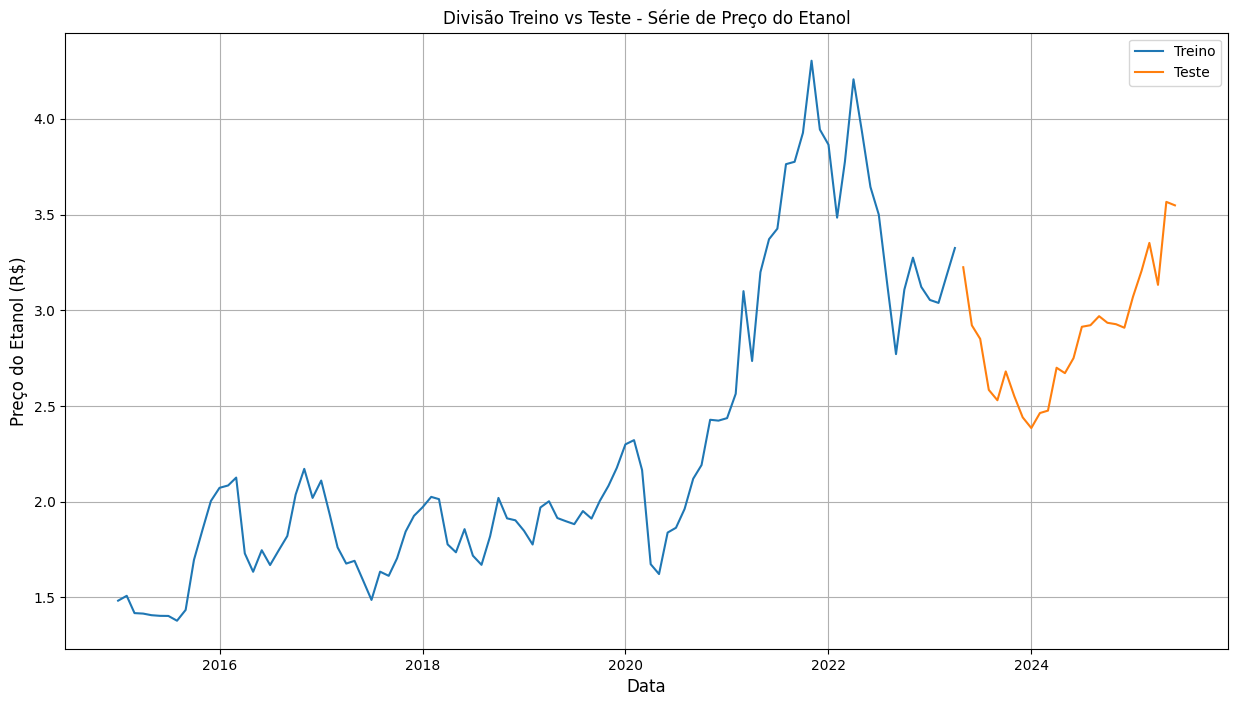

In [ ]:
# Plot dos dados de treino e teste
plt.figure(figsize=(15, 8))

plt.plot(df_treino['Data'], df_treino['À vista R$'], label='Treino')
plt.plot(df_teste['Data'], df_teste['À vista R$'], label='Teste')

plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço do Etanol (R$)', fontsize=12)

plt.title('Divisão Treino vs Teste - Série de Preço do Etanol')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Colocando a data no índice de treino e teste
df_treino = df_treino.set_index('Data')
df_teste = df_teste.set_index('Data')

In [ ]:
#vendo as dimensões da base de dados de treino e teste
print('Training data shape: ', df_treino.shape)
print('Test data shape: ', df_teste.shape)

Training data shape:  (100, 1)
Test data shape:  (26, 1)


#Implementar SARIMA
É hora de implementar o SARIMA! Agora você usará a statsmodels biblioteca que instalou anteriormente.

Agora você precisa seguir vários passos

Defina o modelo chamando SARIMAX()e passando os parâmetros do modelo: parâmetros p, d e q, e parâmetros P, D e Q.
Prepare o modelo para os dados de treinamento chamando a função fit().
Faça previsões chamando a forecast()função e especificando o número de etapas (o horizon) a serem previstas. Para que servem todos esses parâmetros? Em um modelo ARIMA, existem 3 parâmetros usados para ajudar a modelar os principais aspectos de uma série temporal: sazonalidade, tendência e ruído. Esses parâmetros são:

p: o parâmetro associado ao aspecto autorregressivo do modelo, que incorpora valores passados . d: o parâmetro associado à parte integrada do modelo, que afeta a quantidade de diferenciação (lembra da diferenciação?) a ser aplicada a uma série temporal. q: o parâmetro associado à parte da média móvel do modelo.

In [ ]:
#Comece definindo o seu horizonte preferido. Vamos tentar 3 horas:
HORIZON = 24
print('Forecasting horizon:', HORIZON, 'months')

Forecasting horizon: 24 months


In [ ]:
# Usar o dataframe do etanol para a análise
df_analise = df.copy()

# Garantir que a coluna Data está em datetime
df_analise["Data"] = pd.to_datetime(df_analise["Data"])

# Ordenar pela data
df_analise = df_analise.sort_values("Data")

# Calcular índice de corte (80% treino)
corte_idx = int(len(df_analise) * 0.8)

# Dividir treino e teste
df_treino = df_analise.iloc[:corte_idx]
df_teste = df_analise.iloc[corte_idx:]

# Verificar tamanhos
print(f"Tamanho treino: {len(df_treino)}")
print(f"Tamanho teste: {len(df_teste)}")

# Mostrar período de cada conjunto
print("Treino:", df_treino["Data"].min(), "até", df_treino["Data"].max())
print("Teste:", df_teste["Data"].min(), "até", df_teste["Data"].max())

Tamanho treino: 100
Tamanho teste: 26
Treino: 2015-01-01 00:00:00 até 2023-04-01 00:00:00
Teste: 2023-05-01 00:00:00 até 2025-06-01 00:00:00


In [ ]:
import itertools
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Série de treino
serie = df_treino["À vista R$"]

# Intervalos de parâmetros
p = d = q = range(0, 3)
P = D = Q = range(0, 2)

# Sazonalidade mensal
m = 12

# Combinações possíveis
parametros = list(itertools.product(p, d, q))
parametros_sazonais = list(itertools.product(P, D, Q))

resultados = []

print("Testando modelos...")

for param in parametros:
    for param_sazonal in parametros_sazonais:
        try:
            modelo = SARIMAX(
                serie,
                order=param,
                seasonal_order=(param_sazonal[0], param_sazonal[1], param_sazonal[2], m),
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            resultado = modelo.fit(disp=False)

            resultados.append({
                "order": param,
                "seasonal_order": (param_sazonal[0], param_sazonal[1], param_sazonal[2], m),
                "AIC": resultado.aic,
                "BIC": resultado.bic
            })

        except:
            continue

# Criar DataFrame com resultados
df_resultados = pd.DataFrame(resultados)

# Ordenar pelos melhores modelos
df_resultados = df_resultados.sort_values("AIC")

print(df_resultados.head(10))

Testando modelos...
         order seasonal_order    AIC    BIC
24   (0, 1, 0)  (0, 0, 0, 12) -48.42 -45.84
72   (1, 0, 0)  (0, 0, 0, 12) -48.30 -43.11
96   (1, 1, 0)  (0, 0, 0, 12) -46.94 -41.77
32   (0, 1, 1)  (0, 0, 0, 12) -45.74 -40.59
80   (1, 0, 1)  (0, 0, 0, 12) -45.27 -37.52
144  (2, 0, 0)  (0, 0, 0, 12) -45.20 -37.45
184  (2, 1, 2)  (0, 0, 0, 12) -44.96 -32.14
104  (1, 1, 1)  (0, 0, 0, 12) -44.72 -36.99
152  (2, 0, 1)  (0, 0, 0, 12) -44.05 -33.71
168  (2, 1, 0)  (0, 0, 0, 12) -44.02 -36.30


In [ ]:
modelo_final = SARIMAX(
    serie,
    order=(0,1,0),
    seasonal_order=(0,0,0,12)
).fit()

print(modelo_final.summary())

                               SARIMAX Results                                
Dep. Variable:             À vista R$   No. Observations:                  100
Model:               SARIMAX(0, 1, 0)   Log Likelihood                  25.962
Date:                Sun, 22 Mar 2026   AIC                            -49.924
Time:                        21:25:13   BIC                            -47.329
Sample:                             0   HQIC                           -48.874
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0347      0.004      8.112      0.000       0.026       0.043
Ljung-Box (L1) (Q):                   0.41   Jarque-Bera (JB):                 2.65
Prob(Q):                              0.52   Pr

In [ ]:
print(modelo_final.aic)
print(modelo_final.bic)

-49.923867517594125
-47.32874766745954


#Previsão
Aqui faz a previsão dos dados

In [ ]:
# Número de períodos a prever
n_periods = len(df_teste)

# Faz a previsão
forecast = modelo_final.forecast(steps=n_periods)

# Cria série com mesmo índice do teste
forecast_index = df_teste.index
previsao = pd.Series(forecast, index=forecast_index)

# gráfico
Aqui foi feito uma correção no gráfico para unir a série de treino com a série de teste

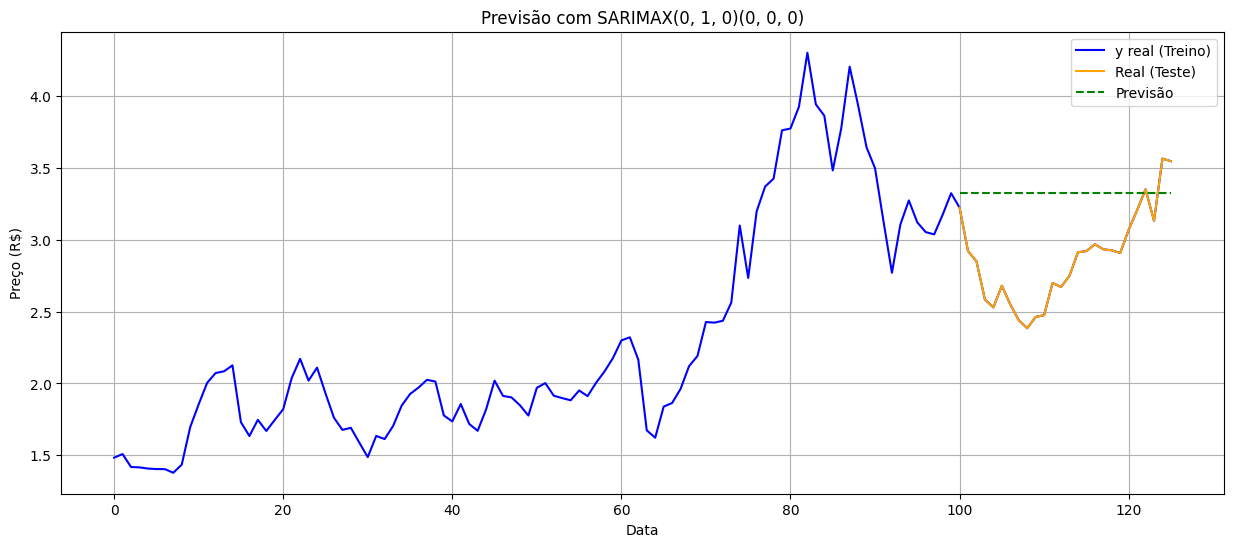

In [ ]:
# Cria uma série contínua com todos os dados reais usando as datas corretas como índice
# Junta os dois dataframes de treino e de teste para serem plotadas continuamente
serie_real_completa = pd.concat([df_treino['À vista R$'], df_teste['À vista R$']])

# Garante que o índice da previsão está em datetime
previsao.index = df_teste.index

# Plotação dos dados
plt.figure(figsize=(15, 6))

# Dados reais completos (treino + teste)
plt.plot(serie_real_completa.index, serie_real_completa, label='y real (Treino)', color='blue')
plt.plot(df_teste.index, df_teste['À vista R$'], label='Real (Teste)', color='orange')

# Previsões apenas no período de teste
plt.plot(previsao.index, previsao, label='Previsão', color='green', linestyle='--')

plt.title('Previsão com SARIMAX(0, 1, 0)(0, 0, 0)')
plt.xlabel('Data')
plt.ylabel('Preço (R$)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Compare as previsões com a carga real:

# Create a DataFrame para comparar valores atuais com previsão
eval_df = pd.DataFrame({
    'atual': df_teste['À vista R$'],
    'previsão': previsao
})

eval_df.head()

,atual,previsão
100,3.22,3.33
101,2.92,3.33
102,2.85,3.33
103,2.58,3.33
104,2.53,3.33


# Métricas de Desempenho (MAE, MAPE, RMSE e sMAPE)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 3. Valores reais do teste
reais = df_teste['À vista R$'].values

# 4. Calcula as métricas
previsoes = previsao.values # Use the defined 'previsao' variable

# MAE
mae = mean_absolute_error(reais, previsoes)

# RMSE
rmse = np.sqrt(mean_squared_error(reais, previsoes))

# MAPE
mape = np.mean(np.abs((reais - previsoes) / reais)) * 100

# sMAPE
smape = np.mean(2 * np.abs(previsoes - reais) / (np.abs(reais) + np.abs(previsoes))) * 100

# 5. Exibe os resultados
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"sMAPE: {smape:.2f}%")

MAE: 0.49
RMSE: 0.55
MAPE: 18.11%
sMAPE: 16.16%
